In [2]:
import numpy as np
import pandas as pd
import sklearn.preprocessing 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set()

In [3]:
from sklearn.datasets import fetch_california_housing


In [6]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print(df.head())
df.to_csv("california_housing.csv", index=False)
print("Saved as california_housing.csv")

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
Saved as california_housing.csv


In [7]:
from sklearn.datasets import fetch_openml

ames = fetch_openml(name="house_prices", as_frame=True)
df_ames = ames.frame

print(df_ames.head())
df_ames.to_csv("ames_housing.csv", index=False)
print("Saved as ames_housing.csv")

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

In [10]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1) Load dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

# 2) Separate features and target
target_col = housing.target_names[0]
X = df.drop(columns=[target_col])
y = df[target_col]

# 3) Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4) Create model
model = LinearRegression()

# 5) Train model
model.fit(X_train, y_train)

# 6) Predict
y_pred = model.predict(X_test)

# 7) Evaluate
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

# 8) Coefficients
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("\nIntercept:", model.intercept_)
print("\nCoefficients:")
print(coef_df.sort_values("Coefficient", ascending=False))

MAE: 0.5332001304956563
MSE: 0.5558915986952437
RMSE: 0.745581383012776
R²: 0.5757877060324512

Intercept: -37.02327770606396

Coefficients:
      Feature  Coefficient
3   AveBedrms     0.783145
0      MedInc     0.448675
1    HouseAge     0.009724
4  Population    -0.000002
5    AveOccup    -0.003526
2    AveRooms    -0.123323
6    Latitude    -0.419792
7   Longitude    -0.433708


In [13]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.feature_selection import RFE

%matplotlib inline
sns.set()

# Load dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame


df.to_csv("california_housing.csv", index=False)

# Basic inspection
print(df.head())
print(df.columns)
print(df.shape)
print(df.info())
print(df.describe())



   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')
(20640, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       2064

In [14]:
print(df.columns)

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')


In [15]:
target_col = housing.target_names[0]

X = df.drop(columns=[target_col])
y = df[[target_col]]

print(X.shape)
print(y.shape)

(20640, 8)
(20640, 1)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=25, shuffle=True
)

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

X_train_scaled.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
8275,0.112212,0.274510,0.019182,0.031630,0.086386,0.001493,0.130851,0.626518
10148,0.624557,0.509804,0.048590,0.025597,0.024834,0.001712,0.144681,0.650810
6720,0.706183,0.882353,0.044082,0.027001,0.030944,0.001553,0.167021,0.629555
18039,0.506255,0.686275,0.042758,0.027907,0.048042,0.001718,0.497872,0.241903
15532,0.221445,0.196078,0.031687,0.026510,0.064327,0.001351,0.067021,0.729757


In [17]:
print(X_train_scaled.shape, y_train.shape)
print(X_test_scaled.shape, y_test.shape)

(14448, 8) (14448, 1)
(6192, 8) (6192, 1)


In [18]:
train_test_split(X, y, test_size=0.30, random_state=25, shuffle=True)

[        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
 8275    2.1270      15.0  3.958746   1.133663      3087.0  2.547030     33.78   
 10148   9.5561      27.0  8.094937   0.981013       891.0  2.819620     33.91   
 6720   10.7397      46.0  7.460993   1.016548      1109.0  2.621749     34.12   
 18039   7.8407      36.0  7.274671   1.039474      1719.0  2.827303     37.23   
 15532   3.7109      11.0  5.717526   1.004124      2300.0  2.371134     33.18   
 ...        ...       ...       ...        ...         ...       ...       ...   
 7324    2.3444      30.0  3.183486   1.051376      2237.0  4.104587     33.98   
 1160    2.9688      24.0  5.526882   0.994624       471.0  2.532258     39.52   
 1175    0.8252      15.0  5.050000   1.350000       145.0  3.625000     39.48   
 2934    1.6981      29.0  5.480176   1.171806       933.0  4.110132     35.36   
 6618    3.4777      47.0  4.873181   1.066528      1537.0  3.195426     34.18   
 
        Longit

In [19]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
pred = model.predict(X_test_scaled)
pred[:5]

array([[1.05328349],
       [2.18010815],
       [2.066581  ],
       [3.00939064],
       [1.95180697]])

In [21]:
model.coef_

array([[ 6.39722640e+00,  4.95072705e-01, -1.68769351e+01,
         1.98555169e+01, -1.21111543e-02, -4.07883366e+00,
        -3.98258947e+00, -4.34040080e+00]])

In [22]:
model.intercept_

array([3.6237365])

In [23]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_.flatten()
})

coef_df.sort_values("Coefficient", ascending=False)

,Feature,Coefficient
3,AveBedrms,19.855517
0,MedInc,6.397226
1,HouseAge,0.495073
4,Population,-0.012111
6,Latitude,-3.982589
5,AveOccup,-4.078834
7,Longitude,-4.340401
2,AveRooms,-16.876935


In [24]:
test_r2 = r2_score(y_test, pred)
train_r2 = r2_score(y_train, model.predict(X_train_scaled))

print("R2 score for testing:", test_r2)
print("R2 score for training:", train_r2)

R2 score for testing: 0.596623451962375
R2 score for training: 0.6085021541759004


In [25]:
mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = mse ** 0.5

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.531153534310348
RMSE: 0.7338560092023261


In [26]:
r_2 = []

for i in range(1, X_test_scaled.shape[1] + 1):
    m = LinearRegression()
    m.fit(X_train_scaled.values[:, :i], y_train)
    prd = m.predict(X_test_scaled.values[:, :i])
    r_2.append(r2_score(y_test, prd))

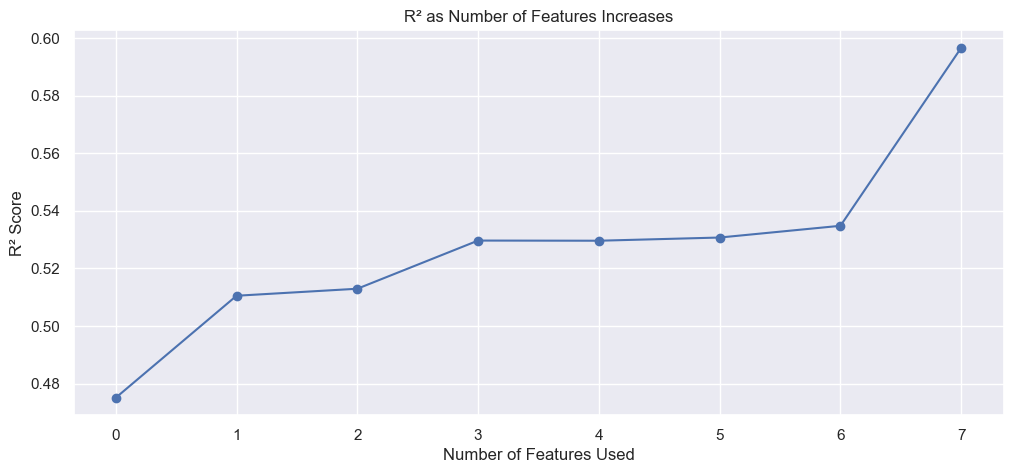

In [27]:
plt.figure(figsize=(12, 5))
plt.plot(r_2, marker='o')
plt.xlabel("Number of Features Used")
plt.ylabel("R² Score")
plt.title("R² as Number of Features Increases")
plt.show()

In [28]:
def adjusted_r2(X_data, r2):
    n = X_data.shape[0]
    p = X_data.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - p - 1))

adj_test_r2 = adjusted_r2(X_test_scaled, test_r2)
print("Adjusted R2 for testing:", adj_test_r2)

Adjusted R2 for testing: 0.5961015350313866


In [29]:
residuals = y_test.values.flatten() - pred.flatten()

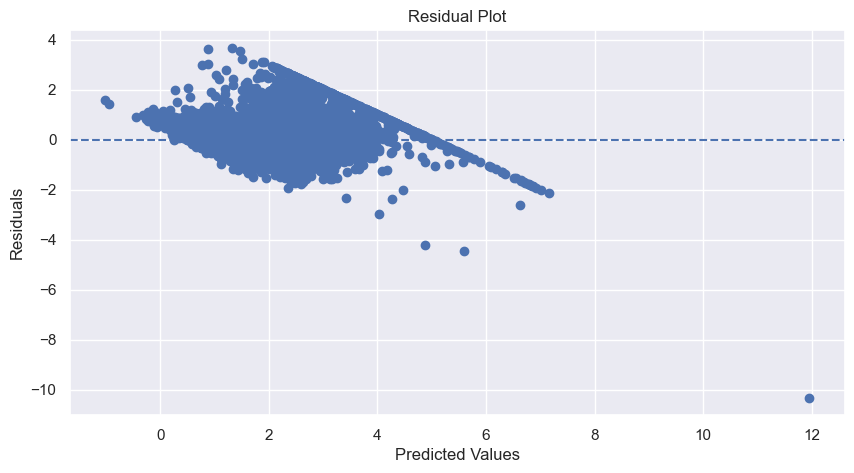

In [30]:
plt.figure(figsize=(10, 5))
plt.scatter(pred, residuals)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

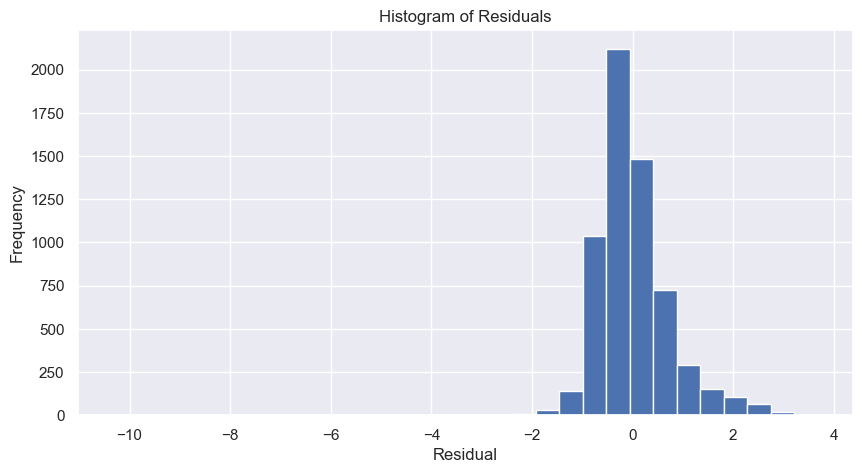

In [31]:
plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()

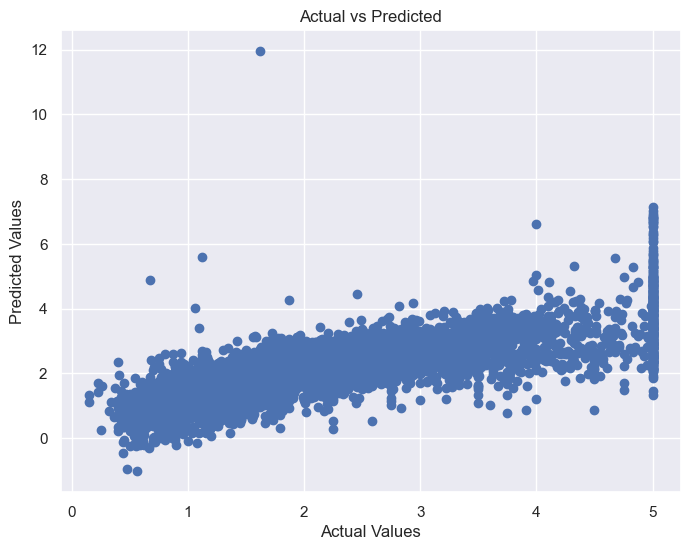

In [32]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

In [33]:
lrm = LinearRegression()

rfe = RFE(estimator=lrm, n_features_to_select=5, step=1)
rfe.fit(X_train_scaled, y_train.values.ravel())

,estimator,LinearRegression()
,n_features_to_select,5
,step,1
,verbose,0
,importance_getter,'auto'
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [34]:
feature_names = np.array(X.columns)

selected_features = list(feature_names[rfe.support_])
print("Selected features:", selected_features)

Selected features: ['MedInc', 'AveRooms', 'AveBedrms', 'Latitude', 'Longitude']


In [35]:
ranking_df = pd.DataFrame({
    "Feature": X.columns,
    "Selected": rfe.support_,
    "Rank": rfe.ranking_
}).sort_values("Rank")

ranking_df

,Feature,Selected,Rank
0,MedInc,True,1
2,AveRooms,True,1
3,AveBedrms,True,1
6,Latitude,True,1
7,Longitude,True,1
5,AveOccup,False,2
1,HouseAge,False,3
4,Population,False,4


In [36]:
X_train_new = X_train_scaled[selected_features]
X_test_new = X_test_scaled[selected_features]

lm2 = LinearRegression()
lm2.fit(X_train_new, y_train)

pred_new = lm2.predict(X_test_new)

print("R-squared value with selected features:", r2_score(y_test, pred_new))
print("Adjusted R2 with selected features:", adjusted_r2(X_test_new, r2_score(y_test, pred_new)))

R-squared value with selected features: 0.5871251074504357
Adjusted R2 with selected features: 0.5867913902724939


In [37]:
scores = cross_val_score(lm2, X_train_new, y_train.values.ravel(), cv=10)

print(scores)
print("Mean CV score:", scores.mean())

[0.62594149 0.62100229 0.59323566 0.60144054 0.58643024 0.59307819
 0.5503293  0.55826873 0.62201048 0.60395491]
Mean CV score: 0.5955691830207852


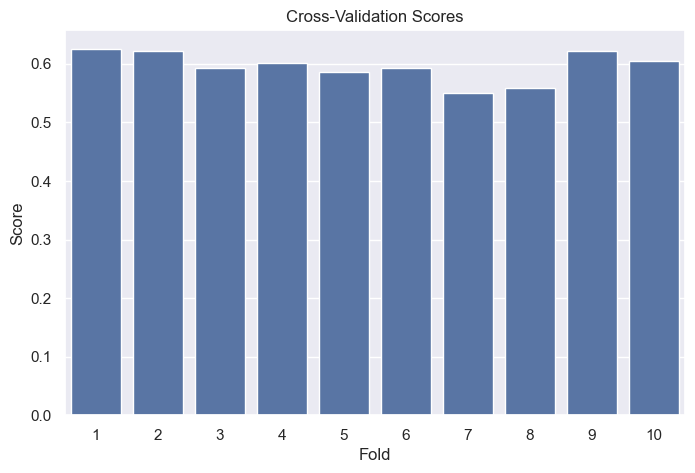

In [38]:
plt.figure(figsize=(8, 5))
sns.barplot(x=list(range(1, len(scores) + 1)), y=scores)
plt.xlabel("Fold")
plt.ylabel("Score")
plt.title("Cross-Validation Scores")
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.feature_selection import RFE

%matplotlib inline
sns.set()

# Load dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

# Save CSV if needed
df.to_csv("california_housing.csv", index=False)

# Basic inspection
print(df.head())
print(df.columns)
print(df.shape)
print(df.info())
print(df.describe())

# Create X and y
target_col = housing.target_names[0]
X = df.drop(columns=[target_col])
y = df[[target_col]]

print(X.shape)
print(y.shape)

# Split first
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=25, shuffle=True
)

# Scale correctly
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

# Train model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Predict
pred = model.predict(X_test_scaled)

# Coefficients and intercept
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_.flatten()
})
print(coef_df.sort_values("Coefficient", ascending=False))

# Scores
test_r2 = r2_score(y_test, pred)
train_r2 = r2_score(y_train, model.predict(X_train_scaled))

print("R2 score for testing:", test_r2)
print("R2 score for training:", train_r2)

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = mse ** 0.5

print("MAE:", mae)
print("RMSE:", rmse)

# R2 with increasing features
r_2 = []
for i in range(1, X_test_scaled.shape[1] + 1):
    m = LinearRegression()
    m.fit(X_train_scaled.values[:, :i], y_train)
    prd = m.predict(X_test_scaled.values[:, :i])
    r_2.append(r2_score(y_test, prd))

plt.figure(figsize=(12, 5))
plt.plot(r_2, marker='o')
plt.xlabel("Number of Features Used")
plt.ylabel("R² Score")
plt.title("R² as Number of Features Increases")
plt.show()

# Adjusted R2
def adjusted_r2(X_data, r2):
    n = X_data.shape[0]
    p = X_data.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("Adjusted R2:", adjusted_r2(X_test_scaled, test_r2))

# Residuals
residuals = y_test.values.flatten() - pred.flatten()

plt.figure(figsize=(10, 5))
plt.scatter(pred, residuals)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

# RFE
lrm = LinearRegression()
rfe = RFE(estimator=lrm, n_features_to_select=5, step=1)
rfe.fit(X_train_scaled, y_train.values.ravel())

feature_names = np.array(X.columns)
selected_features = list(feature_names[rfe.support_])

print("Selected features:", selected_features)

ranking_df = pd.DataFrame({
    "Feature": X.columns,
    "Selected": rfe.support_,
    "Rank": rfe.ranking_
}).sort_values("Rank")

print(ranking_df)

# Train model with selected features
X_train_new = X_train_scaled[selected_features]
X_test_new = X_test_scaled[selected_features]

lm2 = LinearRegression()
lm2.fit(X_train_new, y_train)

pred_new = lm2.predict(X_test_new)

print("R-squared value with selected features:", r2_score(y_test, pred_new))
print("Adjusted R2 with selected features:", adjusted_r2(X_test_new, r2_score(y_test, pred_new)))

# Cross-validation
scores = cross_val_score(lm2, X_train_new, y_train.values.ravel(), cv=10)
print(scores)
print("Mean CV score:", scores.mean())

plt.figure(figsize=(8, 5))
sns.barplot(x=list(range(1, len(scores) + 1)), y=scores)
plt.xlabel("Fold")
plt.ylabel("Score")
plt.title("Cross-Validation Scores")
plt.show()